<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS6 - Transformada Z y respuesta en frecuencia*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Introducción teórica**</u>

En el procesamiento digital de señales, los sistemas discretos se utilizan para modificar o extraer información de señales muestreadas. Una forma habitual de describir estos sistemas es mediante ecuaciones en diferencias, las cuales establecen una relación entre la señal de entrada ($x(n)$) y la señal de salida ($y(n)$). Cuando los coeficientes de estas ecuaciones son constantes, el sistema puede modelarse como un sistema lineal e invariante en el tiempo (*LTI*). 

Una herramienta fundamental para el análisis de sistemas discretos es la **transformada Z**, que permite representar las ecuaciones en diferencias en el dominio complejo. A partir de ella es posible obtener la **función transferencia** del sistema:

$$ 
T(z)=\frac{Y(z)}{X(z)}
$$

donde $Y(z)$ y $X(z)$ representan las transformadas Z de la salida y la entrada, respectivamente. La función transferencia caracteriza completamente el comportamiento del sistema. 

Para estudiar cómo responde el sistema frente a señales sinusoidales de distintas frecuencias, se evalúa la función transferencia sobre la circunferencia de radio unitario ($z=e^{j\Omega}$), obteniéndose la **respuesta en frecuencia**: 

$$
T\!\left(e^{j\Omega}\right) \;=\; T(z)\Big|_{z = e^{j\Omega}}
$$

A partir de esta expresión, se pueden calcular dos magnitudes de interés: 
- **Respuesta de módulo** ($|T(e^{j\Omega})|$): indica la ganancia o atenuación aplicada a cada frecuencia.
- **Respuesta de fase** ($\angle T(e^{j\Omega})$): describe el desplazamiento de fase introducido por el sistema.

Los sistemas analizados en este trabajo corresponden a **filtros *FIR*** (*Finite Impulse Response*), ya que sus salidas dependen únicamente de un número finito de muestras presentes y pasadas de la entrada. Como no poseen realimentación, estos filtros son inherentemente estables y resultan sencillos de implementar y analizar. 

Definición de algunos tipos de filtros que nos van a servir para la resolución y el análisis del presente trabajo. 

### Filtros de media móvil 

Un filtro de **media móvil** es un tipo de filtro FIR que calcula la suma o el promedio de un conjunto de muestras consecutivas de la señal de entrada. Su objetivo principal es suavizar fluctuaciones rápidas y reducir el efecto del ruido presente en la señal. 

De manera general, un filtro de media móvil de longitud *N* puede expresarse como: 

$$
y[n]=\frac{1}{N}\sum_{k=0}^{N-1}x[n-k]
$$

### Filtros pasa-bajos y pasa-altos

Los filtros digitales pueden clasificarse según las frecuencias que permiten pasar con mayor amplitud. 

Un filtro **pasa-bajos** presenta una ganancia elevada para frecuencias bajas y atenúa las componentes de frecuencias altas. Este comportamiento resulta útil para eliminar ruido de alta frecuencia y suavizar señales. Los filtros de media móvil pertenecen a esta clasificación. 

Por otro lado, un filtro **pasa-altos** atenúa las componentes de baja frecuencia y resalta las variaciones rápidas de la señal, asociadas a frecuencias elevadas. Los sistemas basados en diferencias entre muestras consecutivas suelen presentar este comportamiento, ya que eliminan o reducen significativamente la componente continua y las variaciones lentas. 

El análisis de la respuesta en frecuencia permite identificar fácilmente el tipo de filtro implementado, observando como varía el módulo de la función transferencia para las distintas frecuencias. 

En este trabajo se obtendrán las funciones transferencia de diversos sistemas discretos, se calcularán analíticamente sus respuestas en frecuencia y se validarán los resultados mediante simulaciones realizadas en Python. 

# <u>**Desarrollo**</u>

En el presente trabajo se analizaron 4 sistemas discretos definidos mediante ecuaciones en diferencias. El objetivo fue obtener su función de transferencia, calcular analíticamente su respuesta en frecuencia y validar los resultados obtenidos mediante simulaciones en Python.

A continuación, se detallan los procedimientos realizados para cumplir con las consignas propuestas. 

## 1. Obtención de la función transferencia

En primer lugar, se partió de las ecuaciones en diferencias propuestas. Para cada sistema de aplicó la transformada Z. Posteriormente, se despejó la relación entre la transformada de la salida y la transformada de la entrada, para obtener la función transferencia: 
$$
T(z)=\frac{Y(z)}{X(z)}
$$

En la siguiente sección se presenta el desarrollo analítico correspondiente a cada caso. 

In [32]:
from IPython.display import HTML 
HTML(""" <div style="text-align:center;"> <iframe src="Ejercicio 1.pdf" width="800" height="600"></iframe> </div> """)

Una vez obtenidas las funciones de transferencia de los cuatro sistemas, se procedió al análisis de su respuesta en frecuencia. 

## 2. Cálculo de la respuesta en frecuencia 

La respuesta en frecuencia se obtuvo evaluando cada función de transferencia sobre la circunferencia de radio unitario del plano complejo:

$$
T\!\left(e^{j\Omega}\right) \;=\; T(z)\Big|_{z = e^{j\Omega}}
$$

Para cada sistema se calcularon de forma analítica el módulo y la fase de la respuesta en frecuencia. 

In [43]:
from IPython.display import HTML 
HTML(""" <div style="text-align:center;"> <iframe src="Ejercicio 2.pdf" width="800" height="600"></iframe> </div> """)

A partir de estas expresiones fue posible anticipar el comportamiento espectral de cada sistema y determinar a que tipo de filtro corresponde cada una de las ecuaciones en diferencias dadas. 

## 3. Simulación en Python 

Con el objetivo de verificar los resultados obtenidos analíticamente, se implementaron los cuatro sistemas en Python, utilizando funciones de *scipy signal*. 

En primer lugar se importaron las librerias necesarias para el cálculo numérico y para poder realizar los gráficos. 

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

Posteriormente, para cada sistema se definieron mediante vectores los coeficientes correspondientes al numerador y al denominador de $T(z)$, permitiendo calcular numericamente su respuesta en frecuencia. 

Por ejemplo, para el sistema *a* 

$$ 
T(z)=\frac{z^3+z^2+z^1+1}{z^3}
$$

Entonces, los coeficientes utilizados fueron: 

$$ 
b_{coeff}=np.array([1,1,1,1])
$$

$$
a_{coeff}=np.array([1,0,0,0])
$$

De forma análoga se implementaron los restantes sistemas. 

In [38]:
#%% ITEM a 
# T(z) = (z^3 + z^2 + z + 1) / (z^3)

b_coeff_1= np.array([1, 1, 1, 1])
a_coeff_1 = np.array([1, 0, 0, 0]) # Si disminuyo el ultimo coeficiente, bajo el Q, el grafico del modulo es cada vez mas lineal, y la respuesta de fase queda casi lineal 

taps = b_coeff_1.shape[0]

#%% ITEM b
# T(z) = (z^4 + z^3 + z^2 + z + 1) / (z^4)

b_coeff_2 = np.array([1, 1, 1, 1, 1])
a_coeff_2 = np.array([1, 0, 0, 0, 0]) # Si disminuyo el ultimo coeficiente, bajo el Q, el grafico del modulo es cada vez mas lineal, y la respuesta de fase queda casi lineal 

taps = b_coeff_2.shape[0]

#%% ITEM c
# T(z) = (z - 1) / (z)

b_coeff_3 = np.array([1, -1])
a_coeff_3 = np.array([1, 0]) # Si disminuyo el ultimo coeficiente, bajo el Q, el grafico del modulo es cada vez mas lineal, y la respuesta de fase queda casi lineal 

taps = b_coeff_3.shape[0]

#%% ITEM d
# T(z) = (z^2 - 1) / (z^2)

b_coeff_4 = np.array([1, 0, -1])
a_coeff_4 = np.array([1, 0, 0]) # Si disminuyo el ultimo coeficiente, bajo el Q, el grafico del modulo es cada vez mas lineal, y la respuesta de fase queda casi lineal 

taps = b_coeff_4.shape[0]

Una vez definidos los coeficientes de cada filtro, se utilizó la función *freqz()* de *SciPy* para calcular la respuesta en frecuencia. 

$$
omega,\quad resp_{freq} = sig.freqz(b_{coeff}, \quad a = a_{coeff}, \quad worN = 1024)
$$

Esta función permitió obtener la respuesta compleja del sistema en 1024 puntos uniformemente distribuidos entre $0$ y $\pi$ radianes por muestra. 

A partir de dicha respuesta se calculó el módulo mediante $abs(resp_{freq})$ y la fase mediante $phase = np.unwrap(np.angle(resp_{freq})$. 

La función `unwrap()` fue utilizada para eliminar las discontinuidades de $2\pi$ presentes en la representación angular y facilitar la visualización de la fase. 

Luego, para cada uno de los sistemas se generaron gráficos de módulo y fase de la respuesta en frecuencia. En cada figura se representó a ambos parámetros (mósulo y fase) en función de la frecuencia. 

Los gráficos obtenidos permitieron visualizar el comportamiento espectral de cada filtro y comparar los resultados con las predicciones teóricas realizadas a partir de las expresiones analíticas. 

### Sistema *a*

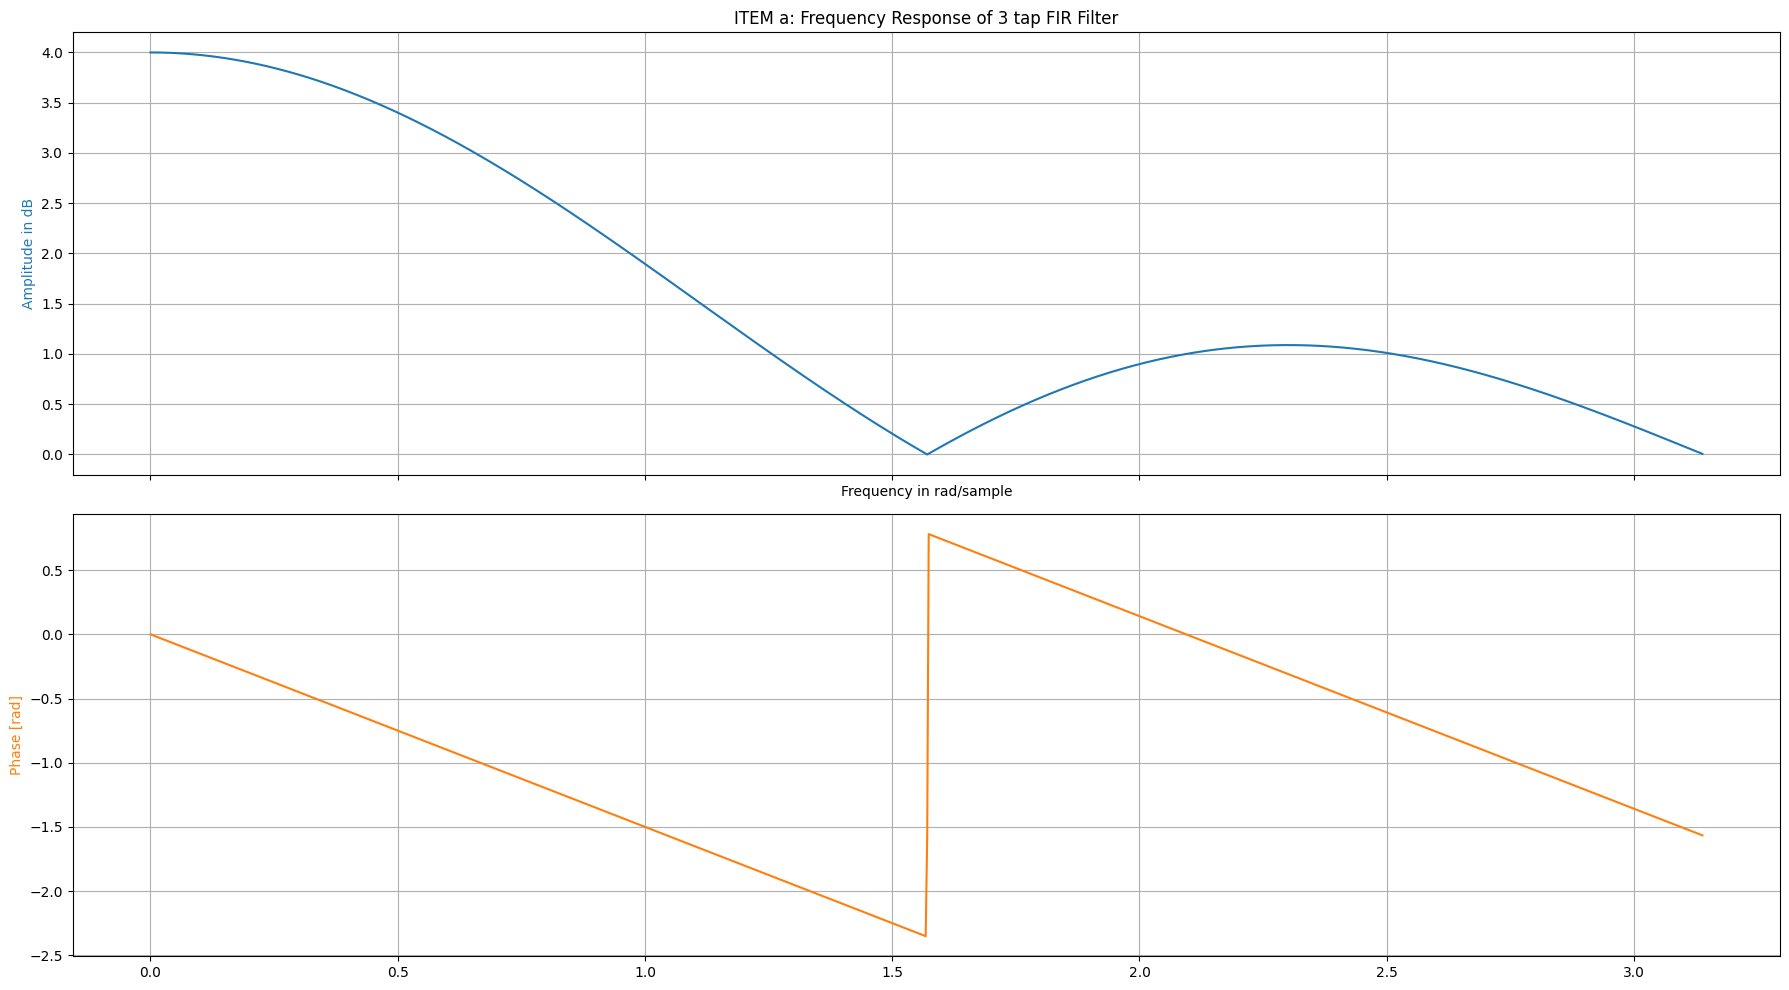

In [39]:
# ITEM a
omega_1, resp_freq_1 = sig.freqz(b_coeff_1, a = a_coeff_1, worN = 1024)

fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize=(18, 10), sharex = True, tight_layout = True)
ax1, ax2 = axs
ax1.set_title(f"ITEM a: Frequency Response of {taps} tap FIR Filter", loc='center') # taps es la cantidad de coeficientes --> me va a dar el orden del filtro 
ax1.plot(omega_1, abs(resp_freq_1), 'C0')
ax1.set_ylabel("Amplitude in dB", color = 'C0')
ax1.grid(True)
ax1.axis('tight')
ax1.set(xlabel="Frequency in rad/sample", xlim = (0, np.pi))

phase_1 = np.unwrap(np.angle(resp_freq_1)) # En este caso si me conviene usar unwrap, porque evito la discontinuidad en la fase

ax2.plot(omega_1, phase_1, 'C1')
ax2.set_ylabel('Phase [rad]', color = 'C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

### Sistema *b*

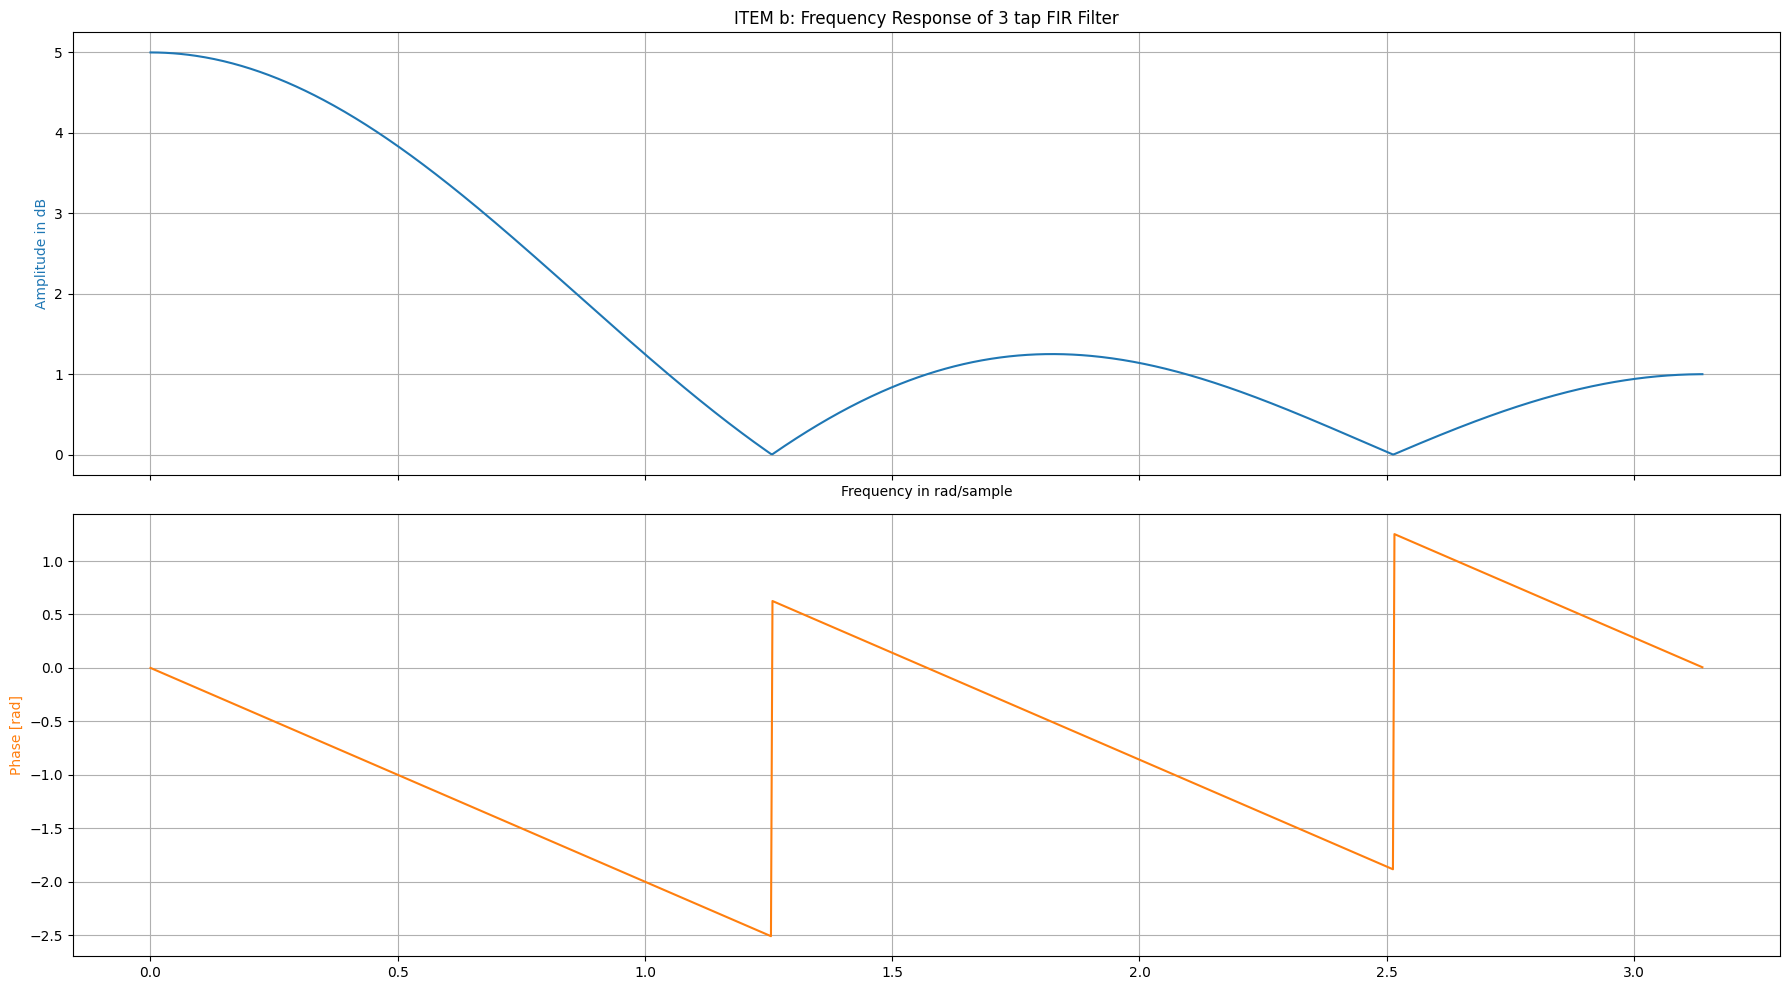

In [40]:
# ITEM b
omega_2, resp_freq_2 = sig.freqz(b_coeff_2, a = a_coeff_2, worN = 1024)

fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize=(18, 10),sharex = True, tight_layout = True)
ax1, ax2 = axs
ax1.set_title(f"ITEM b: Frequency Response of {taps} tap FIR Filter", loc='center') # taps es la cantidad de coeficientes --> me va a dar el orden del filtro 
ax1.plot(omega_2, abs(resp_freq_2), 'C0')
ax1.set_ylabel("Amplitude in dB", color = 'C0')
ax1.grid(True)
ax1.axis('tight')
ax1.set(xlabel="Frequency in rad/sample", xlim = (0, np.pi))

phase_2 = np.unwrap(np.angle(resp_freq_2)) # En este caso si me conviene usar unwrap, porque evito la discontinuidad en la fase

ax2.plot(omega_2, phase_2, 'C1')
ax2.set_ylabel('Phase [rad]', color = 'C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

### Sistema *c*

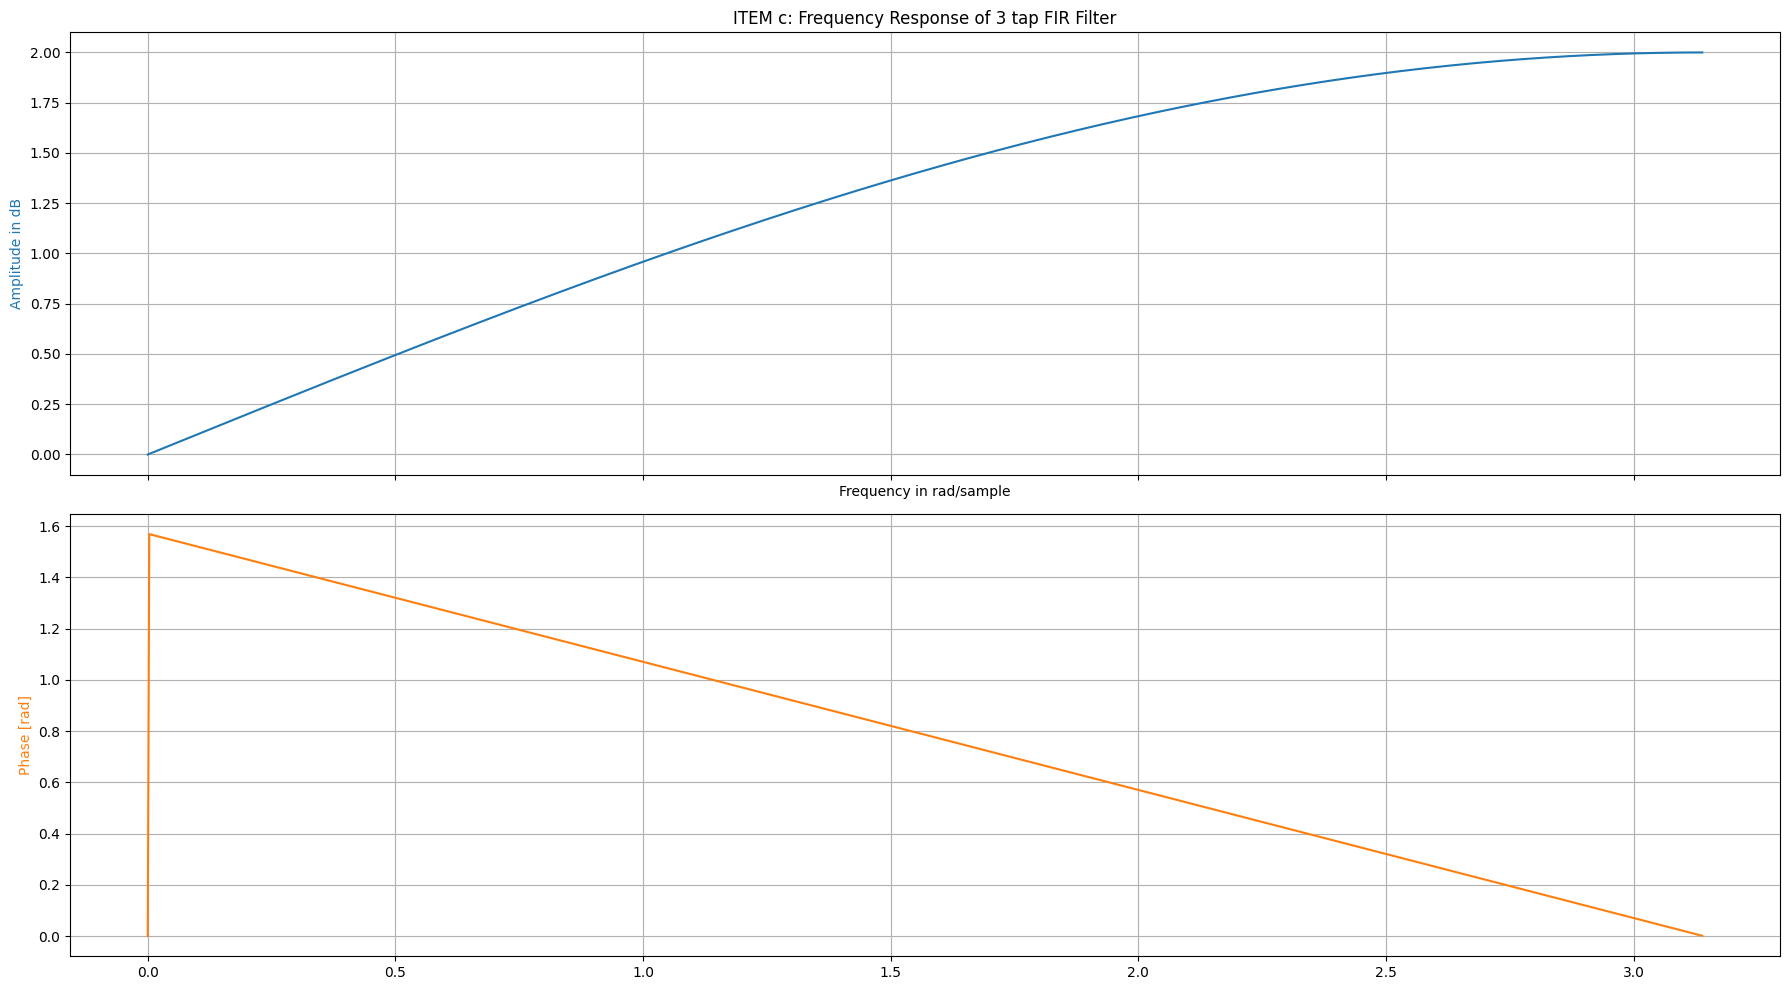

In [41]:
# ITEM c
omega_3, resp_freq_3 = sig.freqz(b_coeff_3, a = a_coeff_3, worN = 1024)

fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize=(18, 10),sharex = True, tight_layout = True)
ax1, ax2 = axs
ax1.set_title(f"ITEM c: Frequency Response of {taps} tap FIR Filter", loc='center') # taps es la cantidad de coeficientes --> me va a dar el orden del filtro 
ax1.plot(omega_3, abs(resp_freq_3), 'C0')
ax1.set_ylabel("Amplitude in dB", color = 'C0')
ax1.grid(True)
ax1.axis('tight')
ax1.set(xlabel="Frequency in rad/sample", xlim = (0, np.pi))

phase_3 = np.unwrap(np.angle(resp_freq_3)) # En este caso si me conviene usar unwrap, porque evito la discontinuidad en la fase

ax2.plot(omega_3, phase_3, 'C1')
ax2.set_ylabel('Phase [rad]', color = 'C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

### Sistema *d*

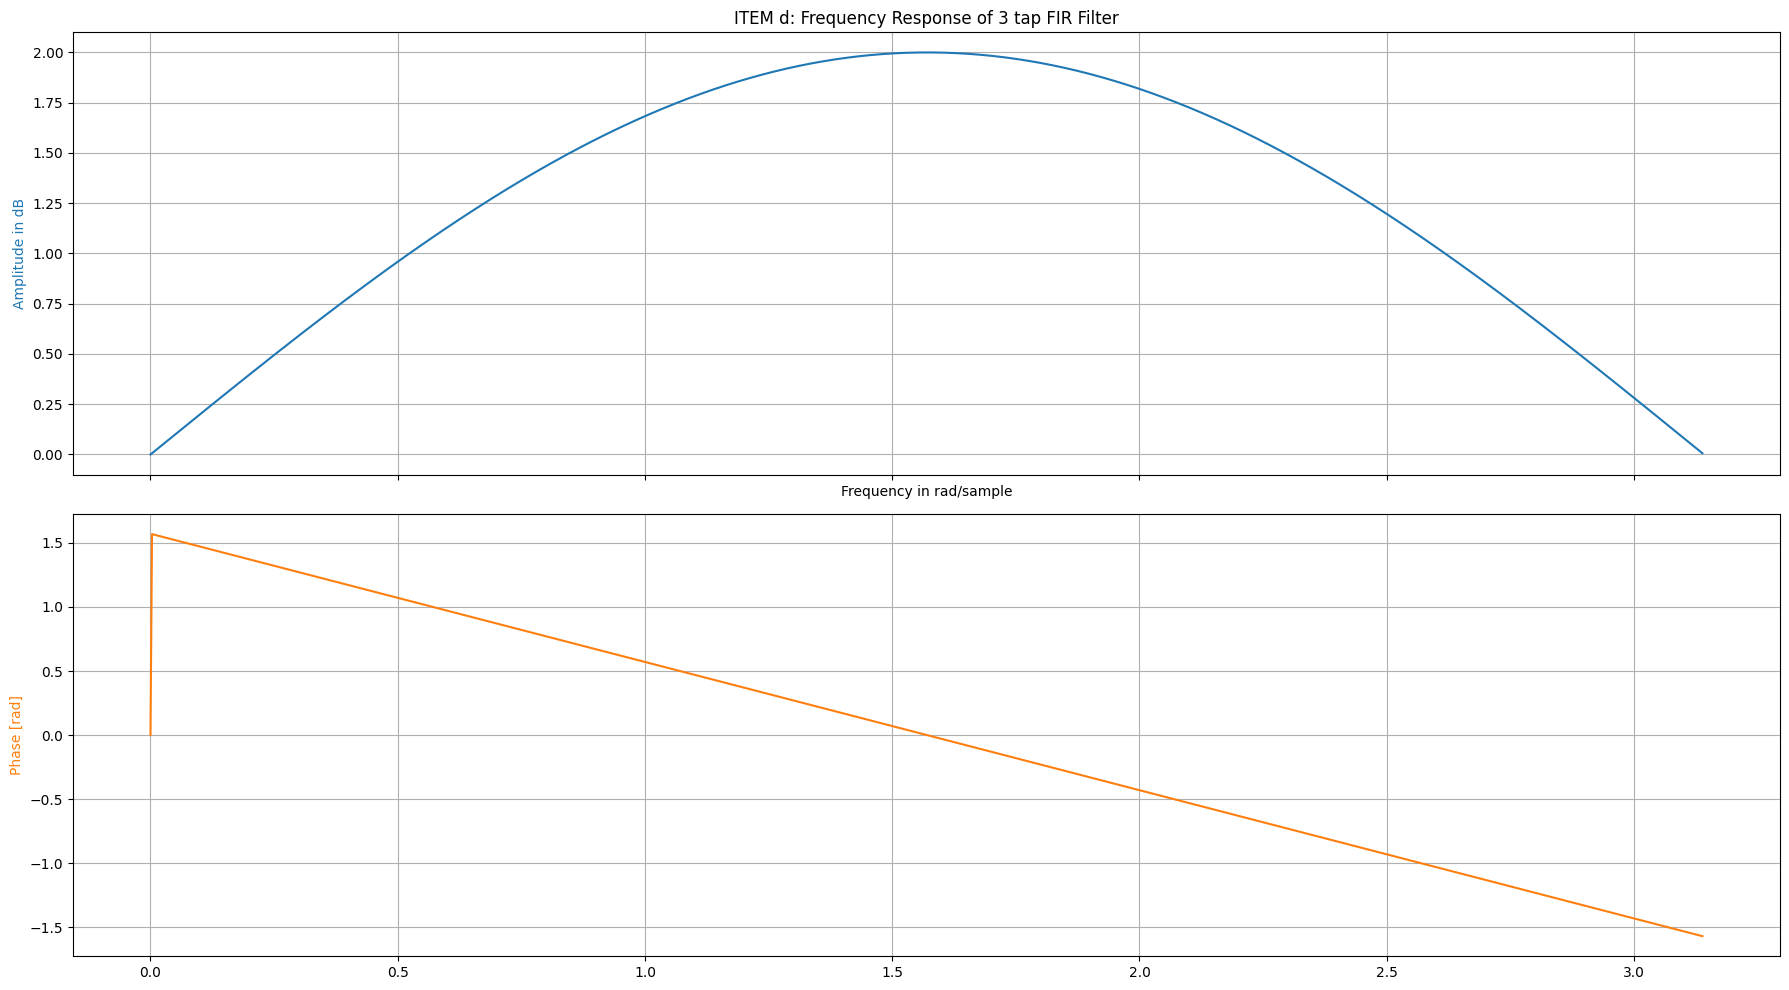

In [42]:
# ITEM d
omega_4, resp_freq_4 = sig.freqz(b_coeff_4, a = a_coeff_4, worN = 1024)

fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize=(18, 10),sharex = True, tight_layout = True)
ax1, ax2 = axs
ax1.set_title(f"ITEM d: Frequency Response of {taps} tap FIR Filter", loc='center') # taps es la cantidad de coeficientes --> me va a dar el orden del filtro 
ax1.plot(omega_4, abs(resp_freq_4), 'C0')
ax1.set_ylabel("Amplitude in dB", color = 'C0')
ax1.grid(True)
ax1.axis('tight')
ax1.set(xlabel="Frequency in rad/sample", xlim = (0, np.pi))

phase_4 = np.unwrap(np.angle(resp_freq_4)) # En este caso si me conviene usar unwrap, porque evito la discontinuidad en la fase

ax2.plot(omega_4, phase_4, 'C1')
ax2.set_ylabel('Phase [rad]', color = 'C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

# <u> **Conclusiones** <u>

A partir de los gráficos obtenidos, se observó que los sistemas *a* y *b*, compuestos por sumas de muestras consecutivas de la señal de entrada, presentan un comportamiento característico de los filtros de media móvil. En consecuencia, actúan como filtros pasa-bajos, atenuando las componentes de alta frecuencia y preservando las de baja frecuencia. 

Por otra parte, los sistemas *c* y *d*, basados en diferencias entre muestras, presentan una fuerte atenuación en bajas frecuencias y una mayor ganancia para frecuencias elevadas, comportándose como filtros pasa-altos. 

La comparación entre los resultados analíticos y los obtenidos mediante simulación mostró una concordancia entre ambas metodologías, validando las expresiones deducidas para la función transferencia y la respuesta en frecuencia de cada sistema. 

Asimismo, el trabajo permitió comprender la relación existente entre las ecuaciones en diferencias, la transformada Z y la respuesta en frecuencia de los sistemas discretos. De esta manera, se verificó que el análisis en el dominio de la frecuencia constituye una herramienta fundamental para caracterizar y predecir el comportamiento de los filtros digitales. 